# 1. Bibliotheken importieren

In [15]:
# Imports

import torch
import torchvision.transforms as transforms
from torchvision import datasets, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os 

In [16]:
# Reproduzierbarkeit & Device

import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# GPU nutzen falls verfügbar - schneller damit das Training und die Inferenzsind, ansonsten CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Seeds gesetzt: {SEED}")
print(f"Device: {device}") # gibt aus ob CPU oder GPU

Seeds gesetzt: 42
Device: cpu


# 2. Datensatz prüfen

In [17]:
# Datensatz prüfen

DATA_DIR = "../data"

#TODO: datenstruktur überprüfen -sinnvoll für andere wenn andere bezeichnung der ordner 
# expected_classes = ["cubism", "pop_art", "realism"]
# for split in ["train", "val", "test"]:
 #   split_path = os.path.join(DATA_DIR, split)
 #   assert os.path.exists(split_path), f"FEHLER: {split} Ordner fehlt!"
 #   for cls in expected_classes:
 #       cls_path = os.path.join(split_path, cls)
 #       assert os.path.exists(cls_path), f"FEHLER: Klasse {cls} fehlt in {split}!"
#print("Datenstruktur OK ✓")

# Klassen und Bildanzahl prüfen
for split in ["train", "val", "test"]:
    split_path = os.path.join(DATA_DIR, split)
    print(f"\n{split.upper()}:")
    for class_name in sorted(os.listdir(split_path)):
        class_path = os.path.join(split_path, class_name)
        if os.path.isdir(class_path):
            count = len([
              f for f in os.listdir(class_path)
              if f.lower().endswith((".jpg", ".jpeg", ".png"))
            ])
            print(f"  {class_name}: {count} Bilder")


TRAIN:
  baroque: 1050 Bilder
  cubism: 1050 Bilder
  pop_art: 1038 Bilder
  realism: 1050 Bilder
  romanticism: 1050 Bilder

VAL:
  baroque: 225 Bilder
  cubism: 225 Bilder
  pop_art: 222 Bilder
  realism: 225 Bilder
  romanticism: 225 Bilder

TEST:
  baroque: 225 Bilder
  cubism: 225 Bilder
  pop_art: 223 Bilder
  realism: 225 Bilder
  romanticism: 225 Bilder


# 3. Preprocessing definieren

In [18]:
# Preprocessing definieren

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transforms definiert:")
print(f"  Training:  {len(train_transform.transforms)} Schritte")
print(f"  Val/Test:  {len(val_test_transform.transforms)} Schritte")

Transforms definiert:
  Training:  4 Schritte
  Val/Test:  3 Schritte


# 4. Daten laden

In [19]:

# Datensatz einlesen

train_dataset = datasets.ImageFolder(
    root=os.path.join(DATA_DIR, "train"),
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    root=os.path.join(DATA_DIR, "val"),
    transform=val_test_transform 
)

test_dataset = datasets.ImageFolder(
    root=os.path.join(DATA_DIR, "test"),
    transform=val_test_transform
    
)

# In Batches aufteilen

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Prüfen

print(f"Klassen: {train_dataset.classes}")
print(f"Klassen-Index: {train_dataset.class_to_idx}")
print(f"\nTraining: {len(train_dataset)} Bilder")
print(f"Validation: {len(val_dataset)} Bilder")
print(f"Test: {len(test_dataset)} Bilder")
print(f"\nBatches im Training: {len(train_loader)}")


Klassen: ['baroque', 'cubism', 'pop_art', 'realism', 'romanticism']
Klassen-Index: {'baroque': 0, 'cubism': 1, 'pop_art': 2, 'realism': 3, 'romanticism': 4}

Training: 5238 Bilder
Validation: 1122 Bilder
Test: 1123 Bilder

Batches im Training: 164


# 5. Modell aufbauen

In [20]:
# Vortrainiertes ResNet18 laden

model = models.resnet18(weights="IMAGENET1K_V1")

# Alle Layer einfrieren

for param in model.parameters():
    param.requires_grad = False

# Letzten Layer ersetzen - 3 Klassen statt 1000

num_classes = len(train_dataset.classes)
model.fc = torch.nn.Linear(512, num_classes)

# Prüfen

print(f"Modell geladen: ResNet18")
print(f"Anzahl Klassen: {num_classes}")
print(f"Klassen: {train_dataset.classes}")
print(f"\nLetzter Layer: {model.fc}")

Modell geladen: ResNet18
Anzahl Klassen: 5
Klassen: ['baroque', 'cubism', 'pop_art', 'realism', 'romanticism']

Letzter Layer: Linear(in_features=512, out_features=5, bias=True)


# 6. Training konfigurieren

In [21]:
# Konfiguration

NUM_EPOCHS = 50                             # Anzahl der Epochen (jetzt 50)
LEARNING_RATE = 0.001                       # Lernrate
PATIENCE = 5                                # Early Stopping Geduld

# Loss-Funktion: Misst wie falsch das Modell liegt
criterion = torch.nn.CrossEntropyLoss()

# Optimizer: Passt nur den letzten Layer an
optimizer = torch.optim.Adam(
    model.fc.parameters(),                  # nur den letzten Layer
    lr=LEARNING_RATE
)

# Prüfen
print(f"Loss-Funktion: CrossEntropyLoss")
print(f"Optimizer: Adam (lr = {LEARNING_RATE})")
print(f"Epochen: {NUM_EPOCHS}")
print(f"Early Stopping Patience: {PATIENCE}")

Loss-Funktion: CrossEntropyLoss
Optimizer: Adam (lr = 0.001)
Epochen: 50
Early Stopping Patience: 5


# 7. Trainingsschleife

In [22]:
torch.manual_seed(SEED)   # Seed festsetzen (Reproduzierbarkeit von Zelle 1)
train_losses = []
val_losses = []
best_val_loss = float('inf')
patience_counter = 0                        # ← neu

for epoch in range(NUM_EPOCHS):

    # ── Training ──────────────────────────────────────────
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # ── Validation ────────────────────────────────────────
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for images, labels in val_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    # ── Ausgabe & Checkpoint ──────────────────────────────
    print(f"Epoche {epoch+1:02}/{NUM_EPOCHS} | "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss:   {avg_val_loss:.4f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0                            # neu: patience zurücksetzen
        torch.save({                                    # neu: Checkpoint Speicherung angepasst 
            "model_state_dict": model.state_dict(),
            "epoch": epoch,
            "val_loss": avg_val_loss,
        }, "../model/best_model.pth")
        print(f"  → Checkpoint gespeichert!")
    else:
        patience_counter += 1                           # ← neu: patience hochzählen
        print(f"  → Keine Verbesserung ({patience_counter}/{PATIENCE})")

    if patience_counter >= PATIENCE:        # ← neu: stoppen
        print(f"\nEarly Stopping nach Epoche {epoch+1}!")
        break

print("\nTraining abgeschlossen!")

Epoche 01/50 | Train Loss: 1.1143 | Val Loss:   0.8608
  → Checkpoint gespeichert!
Epoche 02/50 | Train Loss: 0.8604 | Val Loss:   0.7932
  → Checkpoint gespeichert!
Epoche 03/50 | Train Loss: 0.7945 | Val Loss:   0.7664
  → Checkpoint gespeichert!
Epoche 04/50 | Train Loss: 0.7670 | Val Loss:   0.7436
  → Checkpoint gespeichert!
Epoche 05/50 | Train Loss: 0.7682 | Val Loss:   0.7395
  → Checkpoint gespeichert!
Epoche 06/50 | Train Loss: 0.7346 | Val Loss:   0.7463
  → Keine Verbesserung (1/5)
Epoche 07/50 | Train Loss: 0.7426 | Val Loss:   0.7405
  → Keine Verbesserung (2/5)
Epoche 08/50 | Train Loss: 0.7165 | Val Loss:   0.7928
  → Keine Verbesserung (3/5)
Epoche 09/50 | Train Loss: 0.7180 | Val Loss:   0.7670
  → Keine Verbesserung (4/5)
Epoche 10/50 | Train Loss: 0.7127 | Val Loss:   0.7630
  → Keine Verbesserung (5/5)

Early Stopping nach Epoche 10!

Training abgeschlossen!


# 8. Kurven plotten

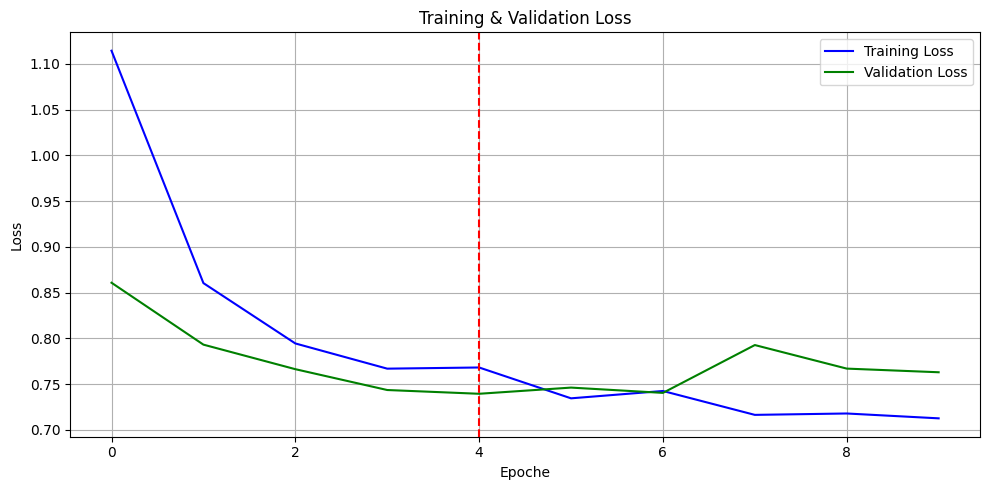


Bester Val Loss: 0.7395 bei Epoche 5


In [28]:
plt.figure(figsize=(10, 5))

plt.plot(train_losses, label="Training Loss", color="blue")
plt.plot(val_losses, label="Validation Loss", color="green")

plt.xlabel("Epoche")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.grid(True)

# Besten Checkpoint markieren

best_epoch = val_losses.index(min(val_losses))
plt.axvline(x=best_epoch, color="red", linestyle="--", label=f"Bester Checkpoint (Epoche {best_epoch+1})")

plt.tight_layout()

os.makedirs("../outputs", exist_ok=True)                                            #Für Streamlit
plt.savefig("../outputs/training_curves.png", dpi=300, bbox_inches="tight")         #Für Streamlit

plt.show()

print(f"\nBester Val Loss: {min(val_losses):.4f} bei Epoche {best_epoch+1}")


# 9. Test-Evaluation

Bestes Modell geladen – Epoche 5, Val Loss: 0.7395
Test Accuracy: 70.35%
Richtig:       790 von 1123 Bildern
              precision    recall  f1-score   support

     baroque       0.66      0.72      0.69       225
      cubism       0.82      0.83      0.82       225
     pop_art       0.85      0.82      0.83       223
     realism       0.59      0.67      0.62       225
 romanticism       0.61      0.49      0.54       225

    accuracy                           0.70      1123
   macro avg       0.70      0.70      0.70      1123
weighted avg       0.70      0.70      0.70      1123



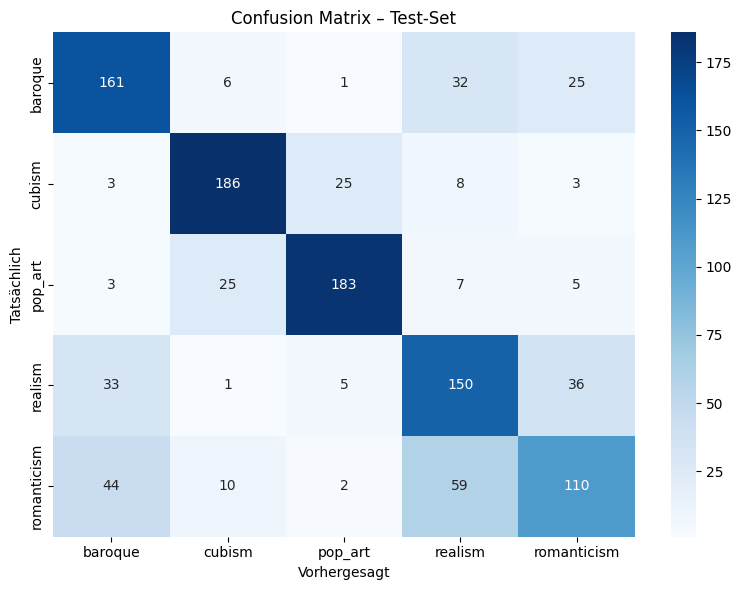

In [ ]:

# Besten Checkpoint laden
checkpoint = torch.load("../model/best_model.pth")
model.load_state_dict(checkpoint["model_state_dict"])
print(f"Bestes Modell geladen – Epoche {checkpoint['epoch']+1}, "
      f"Val Loss: {checkpoint['val_loss']:.4f}")

model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = correct / total * 100

print(f"Test Accuracy: {accuracy:.2f}%")
print(f"Richtig:       {correct} von {total} Bildern")

#TODO: erweitere metriken 

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds,
    target_names=train_dataset.classes))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes,
            cmap="Blues")
plt.xlabel("Vorhergesagt")
plt.ylabel("Tatsächlich")
plt.title("Confusion Matrix – Test-Set")
plt.tight_layout()

os.makedirs("../outputs", exist_ok=True)                                            #Für Streamlit
plt.savefig("../outputs/confusion_matrix.png", dpi=300, bbox_inches="tight")        #Für Streamlit

plt.show()

